# 3D Monte-Carlo simulation based grain strucutres

In [1]:
from upxo.ggrowth.mcgs import mcgs
import matplotlib.pyplot as plt
import seaborn as sns

### Grain strucuture generation
In the `input_dashboard: ..\\gschar3.xls` excel file provided with the repository, we have used the following parameters: 
- `xmin=0, xmax=25, xinc=1`
- `ymin=0, ymax=25, yinc=1`
- `zmin=0, zmax=25, zinc=1`
- `S=8, mcsteps=30, mcalg=300a`
- `state_sampling_scheme=rejection, consider_boltzmann_probability=False`

We will use these to generate a temporal set of grain structures and use the last one available for further work in this notebook.

In [2]:
input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar3.xls'
pxt = mcgs(input_dashboard=input_dashboard)
pxt.simulate(verbose=False) 
tslice = pxt.m[-1]
gstslice = pxt.gs[tslice]
gstslice.char_morphology_of_grains()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\gschar\gschar3.xls
Algo_hops details
(('300a', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 25.0, 1.0
     ymin, ymax, yinc: 0.0, 25.0, 1.0
     zmin, zmax, zinc: 0.0, 25.0, 1.0
     No. of states: 8
     Dimensionality: 3
Using ALG-300a
////////////////////////////////
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 stored
GS temporal slice 17 stored
GS temporal slice 18 st

---

Morphological properties can be accessed from the dictionary ```gstslice.mprop```.
See ```gstslice.mprop.keys()```, contains the following keys:
```Python
dict_keys(['volnv', 'volsr', 'volch', 'sanv', 'savi', 'sasr', 'pernv',
              'pervl', 'pergl', 'eqdia', 'kx', 'ky', 'kz', 'kxyz', 'ksr',
              'arbbox', 'arefit', 'sol', 'ecc', 'com', 'sph', 'fn', 'rnd',
              'mi', 'fdim'])
```
The keys and thier ecxplanations as of 15-08-2024 is proided below:
``` Python
    volnv: Volume by number of voxels
    volsr: Volume after grain boundary surface reconstruction
    volch: Volume of convex hull
    sanv: surface area by number of voxels
    savi: surface area by voxel interfaces
    sasr: surface area after grain boundary surface reconstruction
    pernv: perimeter by number of voxels
    pervl: perimeter by voxel edge lines
    pergl: perimeter by geometric grain boundary line segments
    eqdia: eqvivalent diameter
    kx: grain boundary voxel local curvature in yz plane
    ky: grain boundary voxel local curvature in xz plane
    kz: grain boundary voxel local curvature in xy plane
    kxyz: mean(kx, ky, kz)
    ksr: k computed from surface reconstruction.
    arbbox: aspect ratio by bounding box
    arefit: aspect ratio by ellipsoidal fit
    sol: solidity
    ecc: eccentricity - how much the shape of the grain differs from a sphere.
    com: compactness
    sph: sphericity
    fn: flatness
    rnd: roundness
    mi: moment of inertia tensor
    fdim: fractal dimension
```

In [3]:
gstslice.set_mprops()

---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------


c:\Users\rg5749\AppData\Local\anaconda3\envs\UPXO313a\Lib\site-packages\skimage\measure\_regionprops.py:468: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6013 qhull input error: input is less than 3-dimensional since all points have the same x coordinate    0

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 322218028  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width  2  Error-roundoff 2.5e-15  _one-merge 1.7e-14
  _near-inside 8.6e-14  Visible-distance 4.9e-15  U-max-coplanar 4.9e-15
  Width-outside 9.8e-15  _wide-facet 3e-14  _maxoutside 2e-14

  return convex_hull_image(self.image)
c:\Users\rg5749\AppData\Local\anaconda3\envs\UPXO313a\Lib\site-packages\skimage\measure\_regionprops.py:468: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6214 qhull input error: not enough points(1) to construct initial simplex (need 4)

While executin

---

### Feature query and feature property query

In [4]:
largest_gids = gstslice.get_largest_gids()
print(f"Largest grain ID(s) in this slice: {largest_gids[0]}", f". It has {gstslice.nvoxels[largest_gids[0]]} voxels.\n", 50*'-')
# --------------------------------------------------------
smallest_gids = gstslice.get_smallest_gids()
print(f"Number of smallest grains in this slice: {len(smallest_gids)}.\n", 50*'-')
# --------------------------------------------------------
print(f"Grain ID(s) that are single-voxel grains: {gstslice.single_voxel_grains}.\n", 50*'-')
# --------------------------------------------------------
small_grains_v5 = gstslice.small_grains(vth=5)  # vth: nvoxel threshold
print(f"Grain ID(s) classified as small grains using vth=5: {small_grains_v5}.\n", 50*'-')
# --------------------------------------------------------
large_grains_v20 = gstslice.large_grains(vth=20)  # vth: nvoxel threshold
print(f"Number of grain(s) classified as large using vth=20: {len(large_grains_v20)}.\n", 50*'-')
# --------------------------------------------------------
grains_nvox_2 = gstslice.find_grains_by_nvoxels(nvoxels=2)
print(f"Grain ID(s) with exactly 2 voxels: {grains_nvox_2}.\n", 50*'-')

Largest grain ID(s) in this slice: 56 . It has 2699 voxels.
 --------------------------------------------------
Number of smallest grains in this slice: 84.
 --------------------------------------------------
Grain ID(s) that are single-voxel grains: [  5   6   8   9  11  14  17  21  22  23  24  27  32  34  35  36  37  38
  41  42  46  47  49  50  59  60  61  62  63  64  69  73  74  78  79  80
  82  83  84  85  86  88  89  92  93  95  97 102 107 108 110 113 115 116
 118 119 120 122 124 126 127 132 133 134 135 136 138 139 140 144 153 156
 157 158 159 162 166 167 168 173 176 177 179 180].
 --------------------------------------------------
Grain ID(s) classified as small grains using vth=5: [  4   5   6   8   9  10  11  14  15  17  21  22  23  24  27  31  32  33
  34  35  36  37  38  40  41  42  46  47  48  49  50  52  53  58  59  60
  61  62  63  64  69  71  73  74  78  79  80  82  83  84  85  86  88  89
  92  93  94  95  97 100 102 107 108 110 111 112 113 115 116 118 119 120
 122 124 1

In [5]:
gstslice.find_grains_by_mprop_range(prop_name="volnv", low=10, high=15, 
                    low_ineq="ge", high_ineq="le")  # See doc for more details.

array([ 16,  44,  75, 129, 148, 150, 182])

In [6]:
print(f"largest and smallest volume among the grains in this slice: {gstslice.largest_volume}, {gstslice.smallest_volume}.\n", 50*'-')

largest and smallest volume among the grains in this slice: 2699, 1.
 --------------------------------------------------


In [7]:
print(f"Largest grain IDs and smallest grain IDs are: {gstslice.get_largest_gids()}, {gstslice.get_smallest_gids}.\n", 50*'-')

Largest grain IDs and smallest grain IDs are: [56], <bound method mcgs3_grain_structure.get_smallest_gids of UPXO. gs-tslice.3d. 1799747953552>.
 --------------------------------------------------


In [8]:
gstslice.get_volnv_gids([1, 4, 10])  # Volume by number of voxels for some grain IDs

[865, 5, 2]

---

### LFI values along a line

Let us extract values of a scalar variable along a stright line, with the
straight line being specified by starting and ending coordinate indice
locatoins. We will use the `gstslice.get_values_along_line` command to do this. It returns a numpy array of `lfi` values. _NOTE: The line between the two specified end points is generated using Bresenham algorithm._

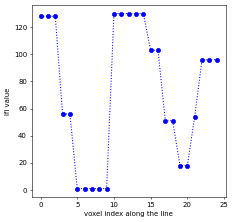

In [9]:
plt.figure(figsize=(5,5), dpi=50)
plt.plot(gstslice.get_values_along_line([0, 0, 0], [24, 23, 24], scalars="lgi"), ':bo')
plt.xlabel("voxel index along the line")
plt.ylabel("lfi value")
plt.show()

### Intercept grain size

We will use the function `.get_igs_along_line()` to get this done. See below cell for implementation. It returns a dictionary of following keys:
- `igs`: value of the metric of igs values.
- `metric`: metric specified by the user.
- `min`: Minimum value. _Key only present if minimum is specified True._
- `max`: Maximum value. _Key only present if maximum is specified True._
- `std`: Std. deviation value. _Key only present if std is specified True._
- `var`: Variance value. _Key only present if variance is specified True._

In [10]:
gstslice.get_igs_along_line([0, 0, 0], [24, 23, 24], metric="mean",
            minimum=True, maximum=True, std=True, variance=True, verbose=True,)

---------------------------------------- 
Getting intercept grain size @line: [0, 0, 0]---[24, 23, 24].


{'igs': np.float64(2.7777777777777777),
 'metric': 'mean',
 'min': np.int64(1),
 'max': np.int64(5),
 'std': np.float64(1.314684396244359),
 'var': np.float64(1.7283950617283952)}

We can extend the above opertation to the entuire RVE now. To this we will use the `.get_igs_along_lines()` function. It produces a dictionary with the folloiwng keys:
- `igs`: overall intercept grain size of the grain structuer.
- `metric`: metric used for calulation of the overall igs value.
- `min`: minimum values of igs in each sampling line.
- `max`: maximum values of igs in each sampling line.
- `std`: standard deviation of igs values in each sampling line.
- `var`: varianbce of igs values in each sampline line.
- `igs_all`: individsual igs over each sampling line.
- `ngrains`: total number of grains in grain structure.

TRY FOR YOURSELF: Explore a similar function `.igs_sed_ratio()`, which helps calculate the ratio of intercept grain size to sphere equivalent diameter.

In [11]:
gstslice.get_igs_along_lines(metric="mean", minimum=True, maximum=True,
    std=True, variance=True, lines_gen_method=1,
    lines_kwargs1={"plane": "z", "start_skip1": 0, "start_skip2": 0,
                   "incr1": 10, "incr2": 10, "inclination": "none", 
                   "inclination_extent": 0, "shift_seperately": False, 
                   "shift_starts": False, "shift_ends": False, "start_shift": 0,
                   "end_shift": 0,},)

{'igs': np.float64(5.0476190476190474),
 'metric': 'mean',
 'min': array([1, 2, 1, 3, 1, 2, 2, 3, 1]),
 'max': array([12,  7, 11,  8, 11, 10, 16, 12,  7]),
 'std': array([3.82970843, 1.63299316, 3.36650165, 2.12132034, 3.24509048,
        3.53553391, 5.88784058, 3.67423461, 2.1602469 ]),
 'var': array([14.66666667,  2.66666667, 11.33333333,  4.5       , 10.53061224,
        12.5       , 34.66666667, 13.5       ,  4.66666667]),
 'igs_all': array([4.        , 4.        , 4.        , 6.        , 3.42857143,
        6.        , 8.        , 6.        , 4.        ]),
 'ngrains': 182}

---

### Surface to sub-surface relationships

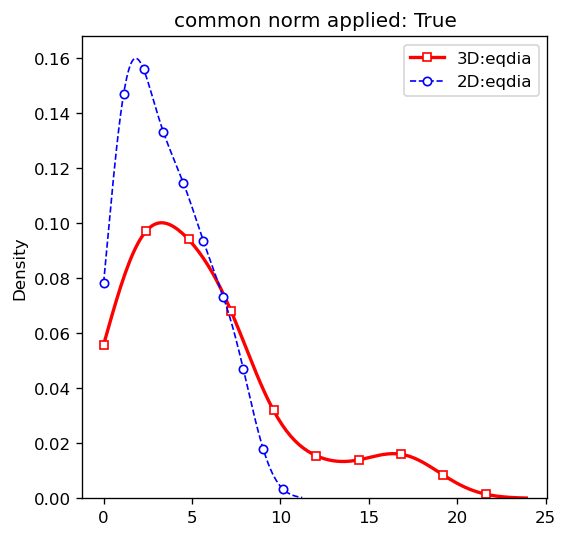

In [13]:
gstslice.sss_rel_morpho(slice_plane='xy', loc=0, reset_lgi=True,
        reset_generators_3d=True, slice_gschar_kernel_order=4,
        mprop_names_2d=['eqdia'], mprop_names_3d=['eqdia'], ignore_border_grains_2d=True,
        ignore_border_grains_3d=True, reset_mprops=False,
        kwargs_arellfit3={'metric': 'max', 'calculate_efits': False,
                          'efit_routine': 1, 'efit_regularize_data': True},
        kwargs_solidity = {'nan_treatment': 'replace', 'inf_treatment': 'replace',
                           'nan_replacement': -1, 'inf_replacement': -1},
        kdeplot=True, save_plot3d_grains=True, ave_plot2d_grains=True, save_plot2d_grains=False,
        figsize=(5, 5), dpi=120)

### Lets extract a slice and characterize it.

We will use the function `.char_lgi_slice_morpho(..)` to get this done. The end results get stored in the dictionary object, `.lgi_slice`. The `.lgi_slice.keys()` will have 4 keys. They are
- `lgi`: Labelled feature IDs.
- `mprop`: Morphological propereties
- `fx`: property generator fuunction
- `gid`: Feature ID (i.e. grain ID)

In [14]:
gstslice.char_lgi_slice_morpho(slice_plane='xy', loc=0, reset_lgi=True, kernel_order=4,
                    mprop_names=['area', 'eqdia', 'fdia', 'perimeter', 'perimeter_crofton',
                                'solidity'], ignore_border_grains_2d=True)

In [15]:
gstslice.lgi_slice.keys()

dict_keys(['lgi', 'mprop', 'fx', 'gid'])

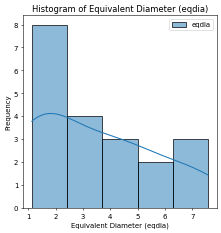

In [16]:
plt.figure(figsize=(5,5), dpi=50)
sns.histplot(gstslice.lgi_slice['mprop']['eqdia'], bins=5, kde=True, label='eqdia')
plt.xlabel('Equivalent Diameter (eqdia)')
plt.ylabel('Frequency')
plt.title('Histogram of Equivalent Diameter (eqdia)')
plt.legend()

---

### Subset extraction

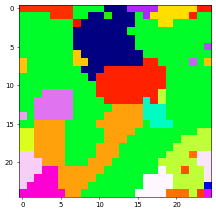

In [17]:
subset_slice = gstslice.get_scalar_field_slice(sf_name='lgi', slice_normal='x',
                    slice_location=0, interpolation='nearest')

plt.figure(figsize=(5,5), dpi=50)
plt.imshow(subset_slice, cmap='gist_ncar')
plt.show()

### Grain structure cleaning

In [18]:
gstslice.clean_gs_GMD_by_source_erosion_v1(prop='volnv', parameter_metric='mean', threshold=1.0,
                            reset_pvgrid_every_iter=False, find_neigh_every_iter=False, find_grvox_every_iter=False,
                            find_grspabnds_every_iter=False, reset_skimrp_every_iter=False)

---------------------------------------- 
Finding grains.
No. of grains detected = 182
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: {sf_name} to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['{sf_name}']
Calculating 1st order neighbours.
    25.0% complete.
    51.0% complete.
    76.0% complete.
----------------------------------------
----------------------------------------
----------------------------------------
---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------
Iteration number: 1

 ++++++++++++++++++++++++++++++++++++++++ 
           Threshold value: 1
 ++++++++++++++++++++++++++++++++++++++++
mvg: [  5   6   8   9  11  14  17  21  22  23  24  27  32  34  35  36  37  38
  41  42  46  47  49  50  59  60  61  62  63  64  69  73  74  78  79  80
  82  83  84  85  86

---

### Visualization

In [20]:
# gstslice.plot_grains(gids=gstslice.large_grains(vth=0.5*gstslice.nvoxels_values.max()), opacity=1.0)